In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("customer_data.csv.txt")

df.head()

,CustomerID,Name,Age,City,Sales
0,101,Rahul,25.0,Delhi,5000.0
1,102,Priya,28.0,Mumbai,7000.0
2,103,Amit,NaN,Delhi,6000.0
3,104,Sneha,22.0,Mumbai,7000.0
4,104,Sneha,22.0,Mumbai,7000.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  8 non-null      int64  
 1   Name        8 non-null      object 
 2   Age         7 non-null      float64
 3   City        7 non-null      object 
 4   Sales       7 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 452.0+ bytes


In [4]:
print(df.isnull().sum())

CustomerID    0
Name          0
Age           1
City          1
Sales         1
dtype: int64


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [6]:
df['City'] = df['City'].fillna('Unknown')

In [7]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

In [8]:
print(df.isnull().sum())

CustomerID    0
Name          0
Age           0
City          0
Sales         0
dtype: int64


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.shape)

(7, 5)


In [11]:
df['Name'] = df['Name'].str.title()

In [12]:
df['City'] = df['City'].str.title()

In [13]:
summary = df.describe()

summary

,CustomerID,Age,Sales
count,7.000000,7.000000,7.000000
mean,104.000000,26.244898,6591.836735
std,2.160247,2.505388,931.966582
min,101.000000,22.000000,5000.000000
25%,102.500000,25.357143,6250.000000
50%,104.000000,26.000000,6642.857143
75%,105.500000,27.500000,7000.000000
max,107.000000,30.000000,8000.000000


In [14]:
total_sales = df['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 46142.857142857145


In [15]:
average_sales = df['Sales'].mean()

print("Average Sales:", average_sales)

Average Sales: 6591.836734693878


In [16]:
city_sales = df.groupby('City')['Sales'].sum()

print(city_sales)

City
Bangalore     6642.857143
Delhi        17500.000000
Mumbai       14000.000000
Unknown       8000.000000
Name: Sales, dtype: float64


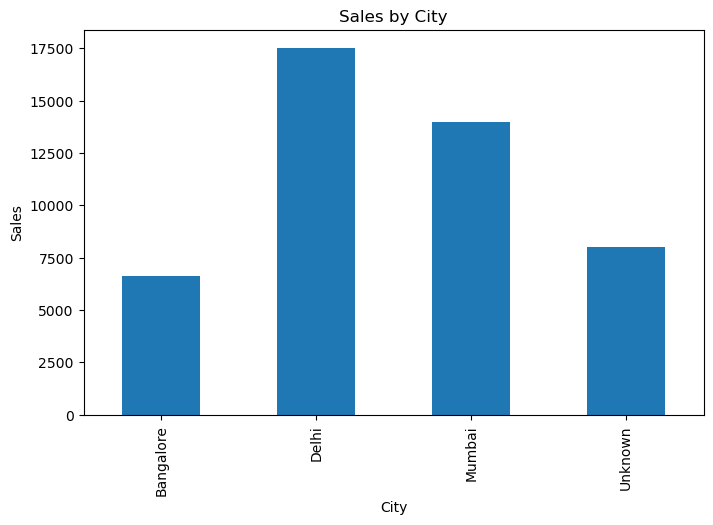

In [17]:
city_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")

plt.show()

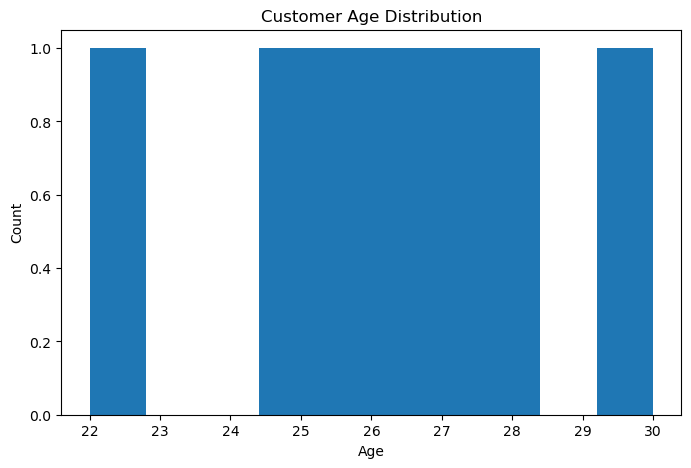

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'])

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [19]:
df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [20]:
with pd.ExcelWriter(
    "cleaned_report.xlsx",
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary Statistics"
    )

print("Report Generated")

Report Generated


In [21]:
def automate_reporting(file_name):

    df = pd.read_csv(file_name)

    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['City'] = df['City'].fillna('Unknown')
    df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

    df = df.drop_duplicates()

    summary = df.describe()

    with pd.ExcelWriter(
        "final_report.xlsx",
        engine="openpyxl"
    ) as writer:

        df.to_excel(
            writer,
            sheet_name="Cleaned Data",
            index=False
        )

        summary.to_excel(
            writer,
            sheet_name="Summary"
        )

    print("Automation Completed")

In [23]:
automate_reporting("customer_data.csv.txt")

Automation Completed
